In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("loan-train.csv")

In [8]:
df.shape

(614, 13)

In [9]:
df.sample(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
240,LP001798,Male,Yes,2,Graduate,No,5819,5000.0,120.0,360.0,1.0,Rural,Y
406,LP002308,Male,Yes,0,Not Graduate,No,2167,2400.0,115.0,360.0,1.0,Urban,Y
103,LP001356,Male,Yes,0,Graduate,No,4652,3583.0,NaN,360.0,1.0,Semiurban,Y
215,LP001720,Male,Yes,3+,Not Graduate,No,3850,983.0,100.0,360.0,1.0,Semiurban,Y
515,LP002659,Male,Yes,3+,Graduate,No,3466,3428.0,150.0,360.0,1.0,Rural,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N
420,LP002348,Male,Yes,0,Graduate,No,5829,0.0,138.0,360.0,1.0,Rural,Y
574,LP002863,Male,Yes,3+,Graduate,No,6406,0.0,150.0,360.0,1.0,Semiurban,N
96,LP001327,Female,Yes,0,Graduate,No,2484,2302.0,137.0,360.0,1.0,Semiurban,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y


##### As loan id won't help much in interpretation so we will drop it

In [10]:
df= df.drop(columns='Loan_ID')

In [11]:
df.sample(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
576,NaN,Yes,0,Graduate,No,3087,2210.0,136.0,360.0,0.0,Semiurban,N
563,Male,No,0,Not Graduate,Yes,5800,0.0,132.0,360.0,1.0,Semiurban,Y
548,Female,No,0,Graduate,No,5000,0.0,103.0,360.0,0.0,Semiurban,N
396,Female,No,0,Graduate,No,3180,0.0,71.0,360.0,0.0,Urban,N
553,Male,Yes,0,Not Graduate,No,2454,2333.0,181.0,360.0,0.0,Urban,N
523,Male,Yes,2,Graduate,Yes,7948,7166.0,480.0,360.0,1.0,Rural,Y
128,Male,Yes,1,Graduate,Yes,10513,3850.0,160.0,180.0,0.0,Urban,N
189,Male,Yes,0,Graduate,No,9328,0.0,188.0,180.0,1.0,Rural,Y
603,Male,No,0,Graduate,No,3676,4301.0,172.0,360.0,1.0,Rural,Y
562,Male,Yes,0,Graduate,No,5923,2054.0,211.0,360.0,1.0,Rural,Y


In [12]:
df.shape

(614, 12)

In [13]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [15]:
df.nunique()

Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [16]:
cat_cols = [features for features in df.drop(columns='Loan_Status').columns if df[features].dtype =='object']

In [17]:
cat_cols

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area']

In [18]:
for col in cat_cols:
    print(f"The categories in {col} are : {df[col].dropna().unique()}")

The categories in Gender are : ['Male' 'Female']
The categories in Married are : ['No' 'Yes']
The categories in Dependents are : ['0' '1' '2' '3+']
The categories in Education are : ['Graduate' 'Not Graduate']
The categories in Self_Employed are : ['No' 'Yes']
The categories in Property_Area are : ['Urban' 'Rural' 'Semiurban']


In [19]:
num_cols = [features for features in df.columns if df[features].dtype != 'object']
num_cols

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
cor = df.select_dtypes(include='number').corr()

<Axes: >

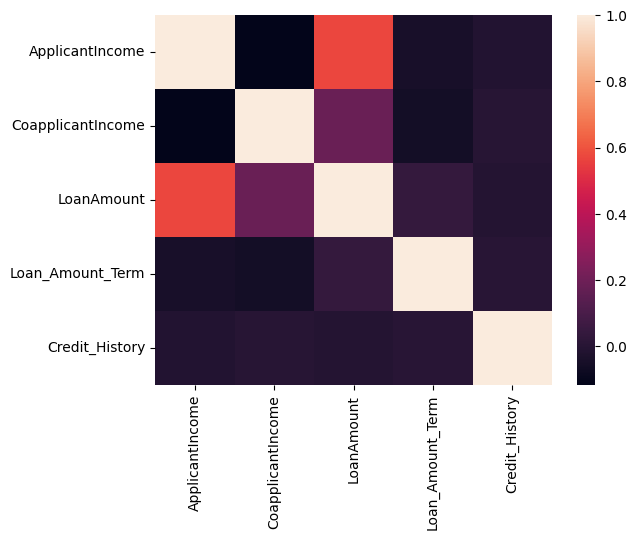

In [22]:
sns.heatmap(cor)

##### There is no as such strong correlation between two columns

### ***Univariate Analysis***

In [23]:
cat_cols.append('Credit_History')
cat_cols

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Credit_History']

In [24]:
len(cat_cols)

7

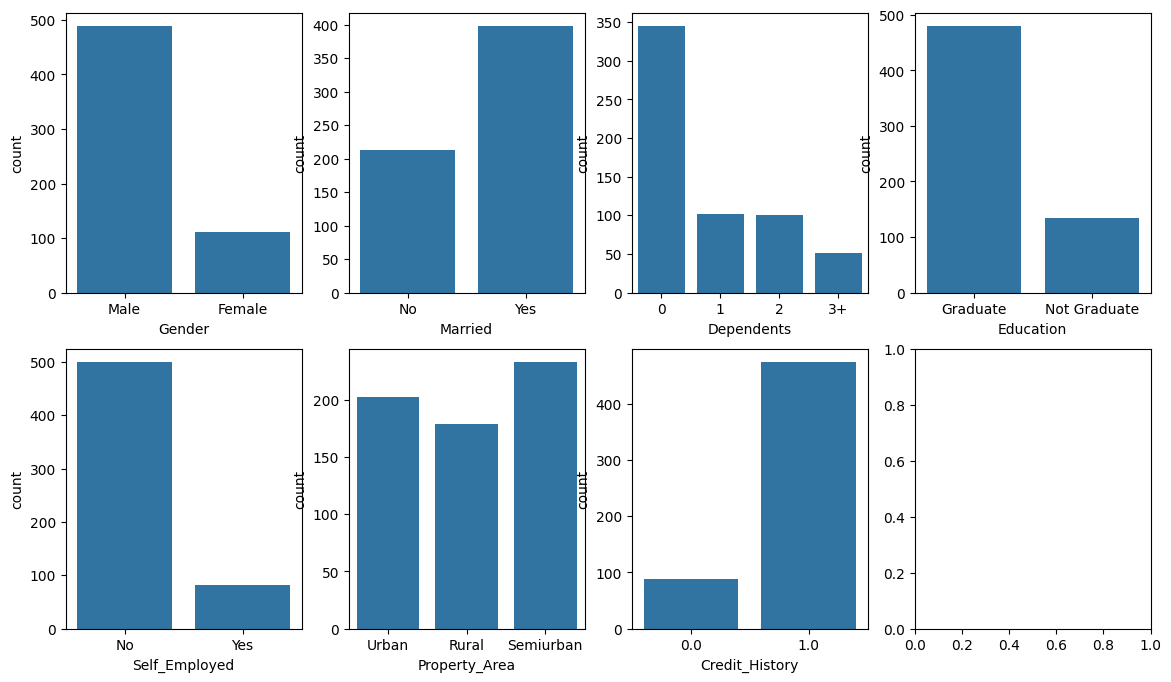

In [25]:
fig , axes = plt.subplots(2,4 , figsize=(14,8))
axes = axes.flatten()
i=0
for col in cat_cols:
    sns.countplot(x=col,data=df,ax=axes[i])
    i = i+1

In [26]:
num_cols.pop()
num_cols

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

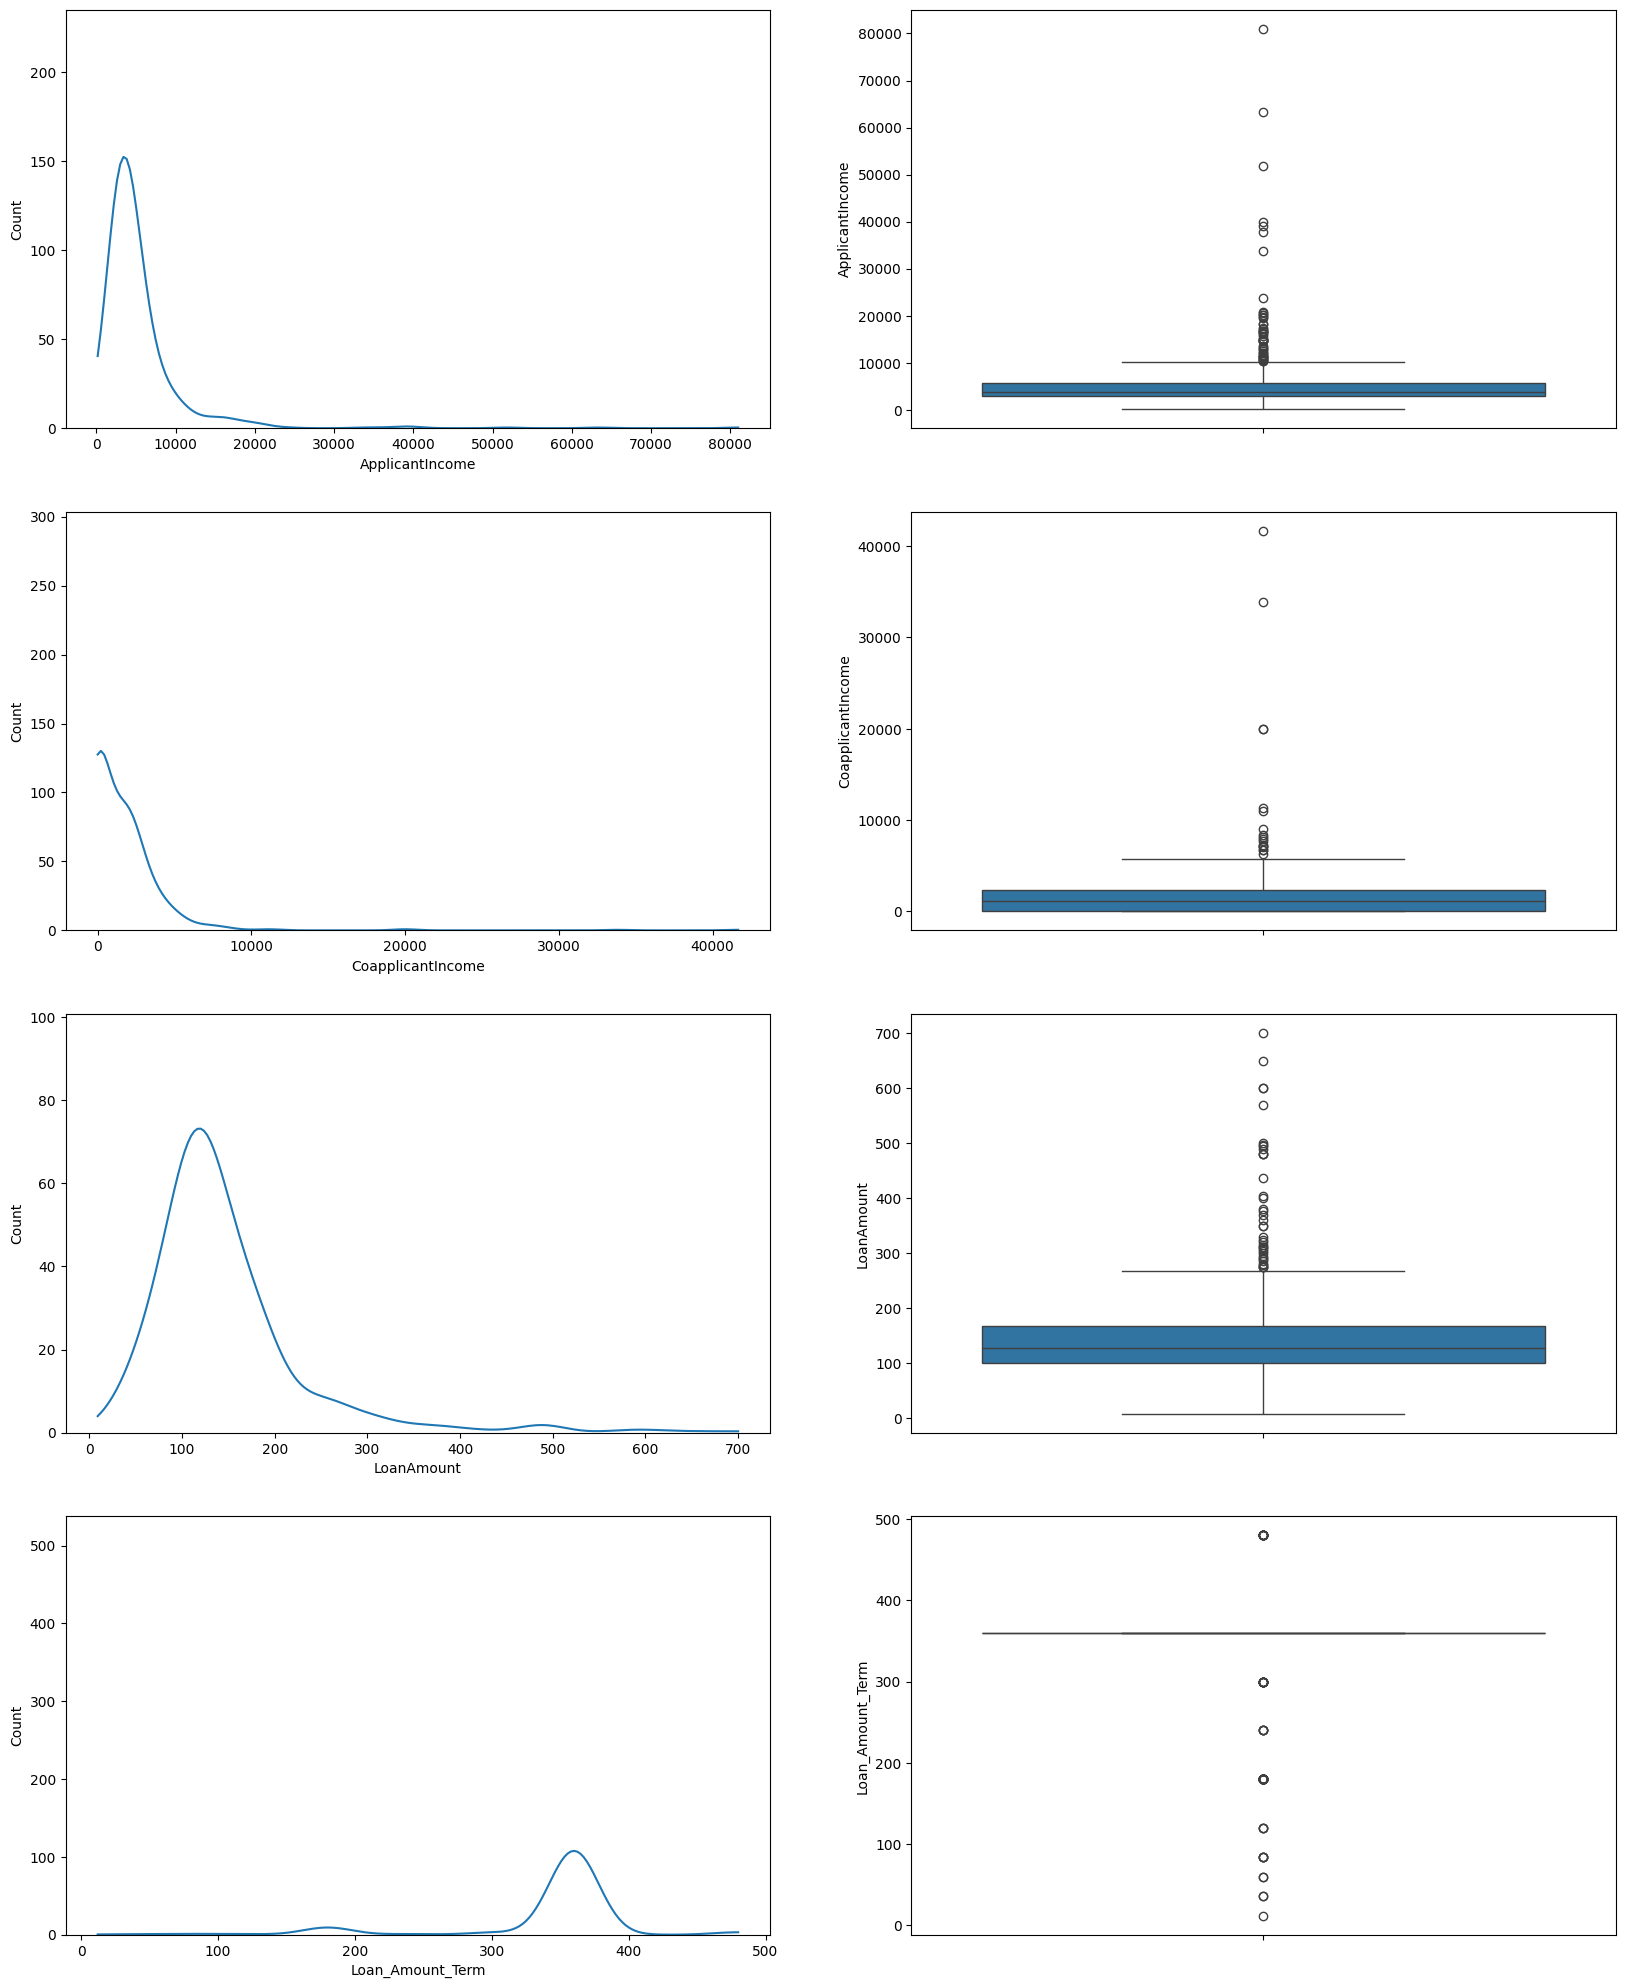

In [27]:
fig,axes = plt.subplots(4,2,figsize=(20,25))
axes = axes.flatten()
i =0
for cols in num_cols:
    sns.histplot(df[cols],kde=True,fill=False,linewidth=0,ax=axes[i])
    sns.boxplot(df[cols],ax=axes[i+1])
    i+=2

##### This tells us about presence of outliers

In [28]:
from scipy.stats import zscore

In [29]:
for cols in num_cols :
    print(f"for {cols}")
    print(df[abs(zscore(df[cols])) > 3].shape)
    print('='*35)

for ApplicantIncome
(8, 12)
for CoapplicantIncome
(6, 12)
for LoanAmount
(0, 12)
for Loan_Amount_Term
(0, 12)


### ***Bivariate Analysis***

In [30]:
cat_cols

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Credit_History']

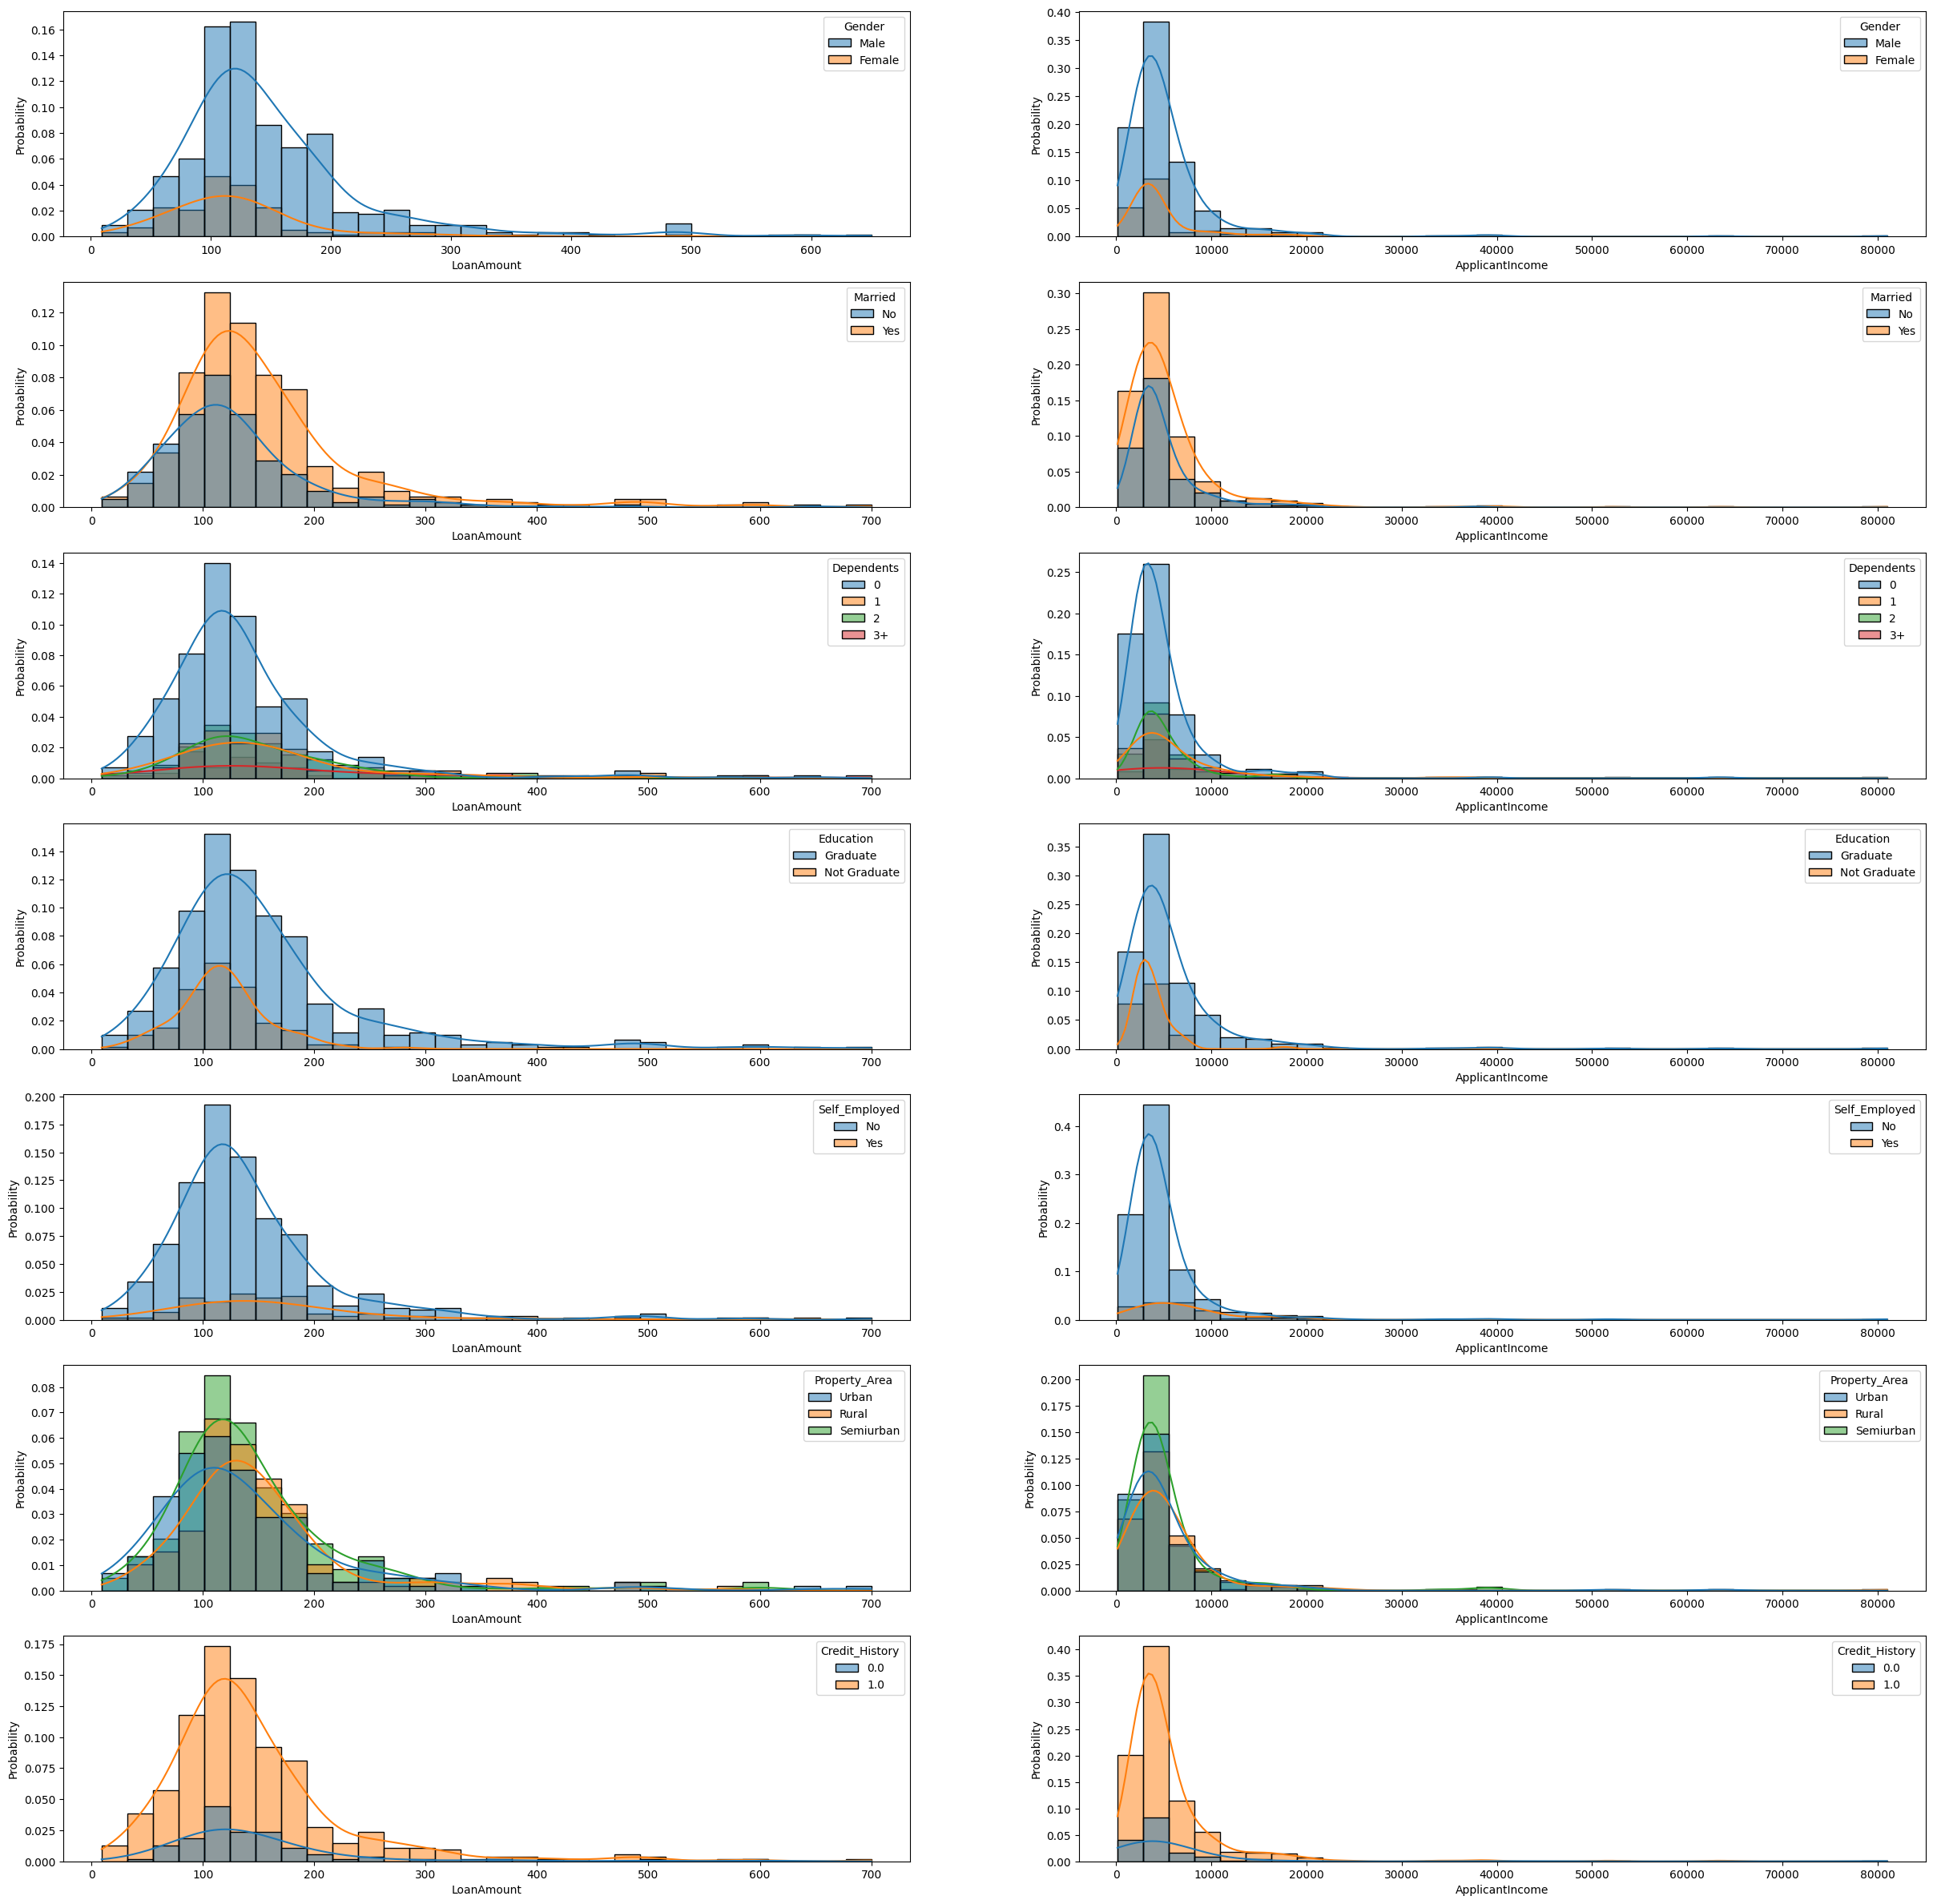

In [31]:
fig , axes = plt.subplots(7,2, figsize=(30,30))
axes = axes.flatten()
i =0 
for cols in cat_cols:
    sns.histplot(x='LoanAmount',hue=cols,kde=True,stat='probability',ax=axes[i],bins=30,data=df)
    sns.histplot(x='ApplicantIncome',hue=cols,kde=True,stat='probability',ax= axes[i+1],data=df,bins=30)
    i = i+2

#### Bivariate Analysis for the categorical and target column

In [32]:
Married = pd.crosstab(df['Married'],df['Loan_Status'])

<Axes: xlabel='Married'>

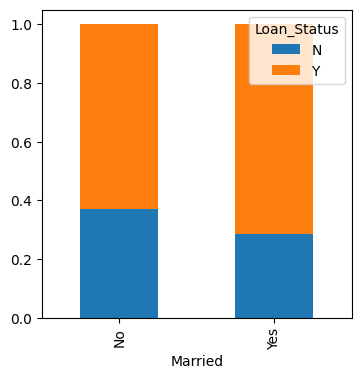

In [33]:
Married.div(Married.sum(axis=1).astype(float),axis=0).plot(kind='bar',stacked=True,figsize=(4,4))

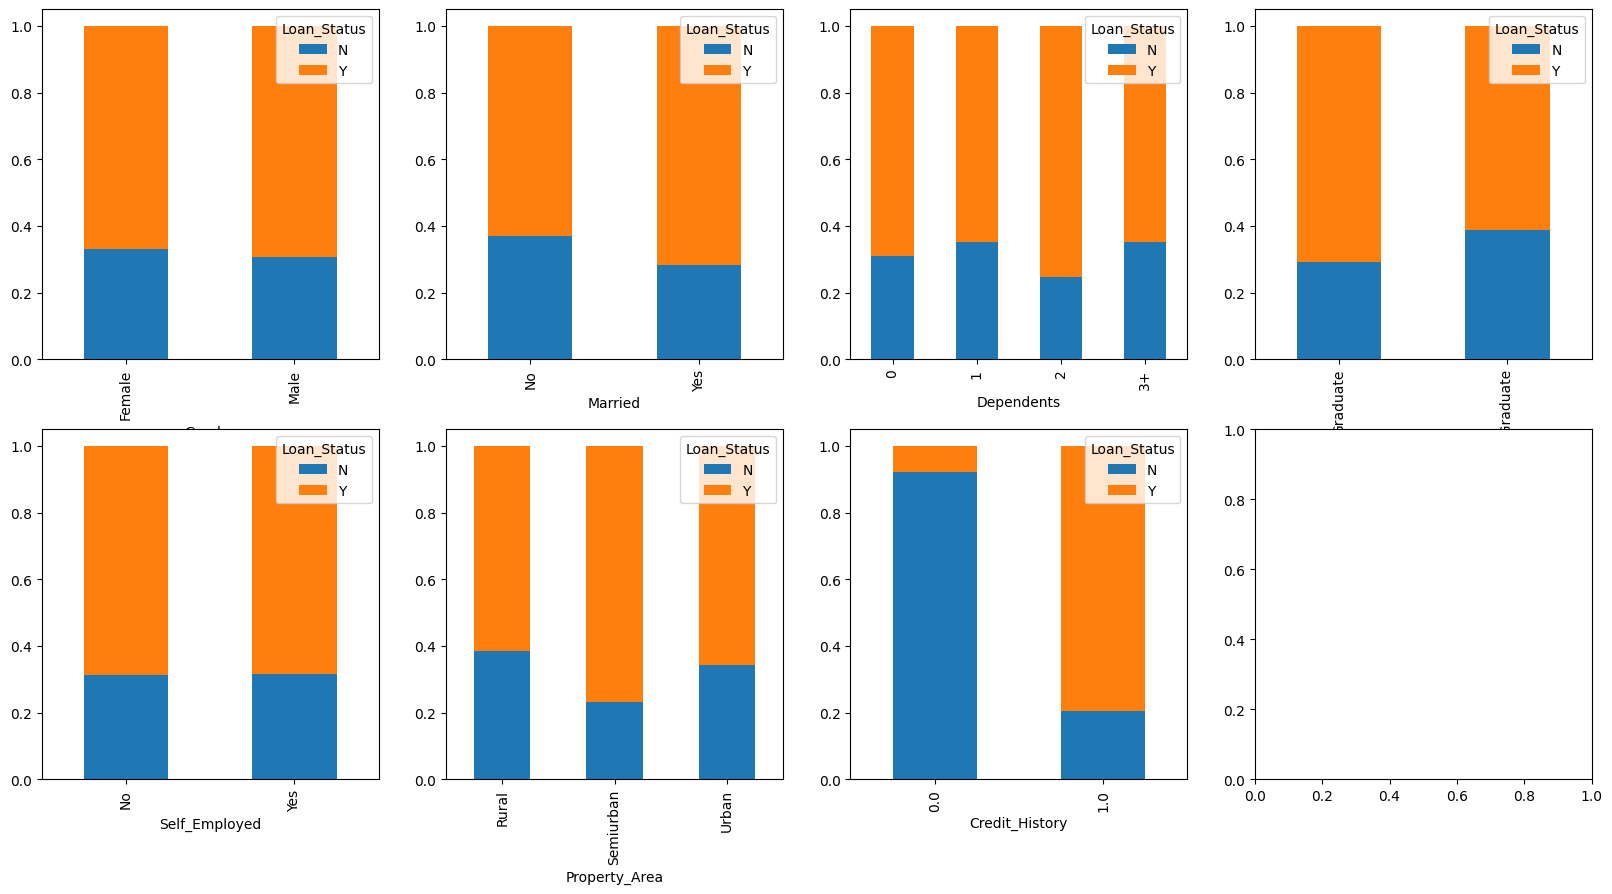

In [34]:
fig , axes = plt.subplots(2,4,figsize=(20,10))
axes = axes.flatten()
i=0
for cols in cat_cols:
    val = pd.crosstab(df[cols],df['Loan_Status'])
    val.div(val.sum(axis=1).astype(float),axis=0).plot(kind='bar',stacked=True,ax=axes[i])
    i+=1

#### It states that the proportion of male and female applicants is more or less same for approved or disapproved of loan

##### Amongst dependents the applicant with 2 dependents has higher proportion of loan being approved

##### Graduated has higher proportion of loan being approved

##### Applicant in semi urban has higher proportion of loan being approved

##### Applicant with 1 credit history has higher proportion of getting loan approved

##### Now for numerical columns

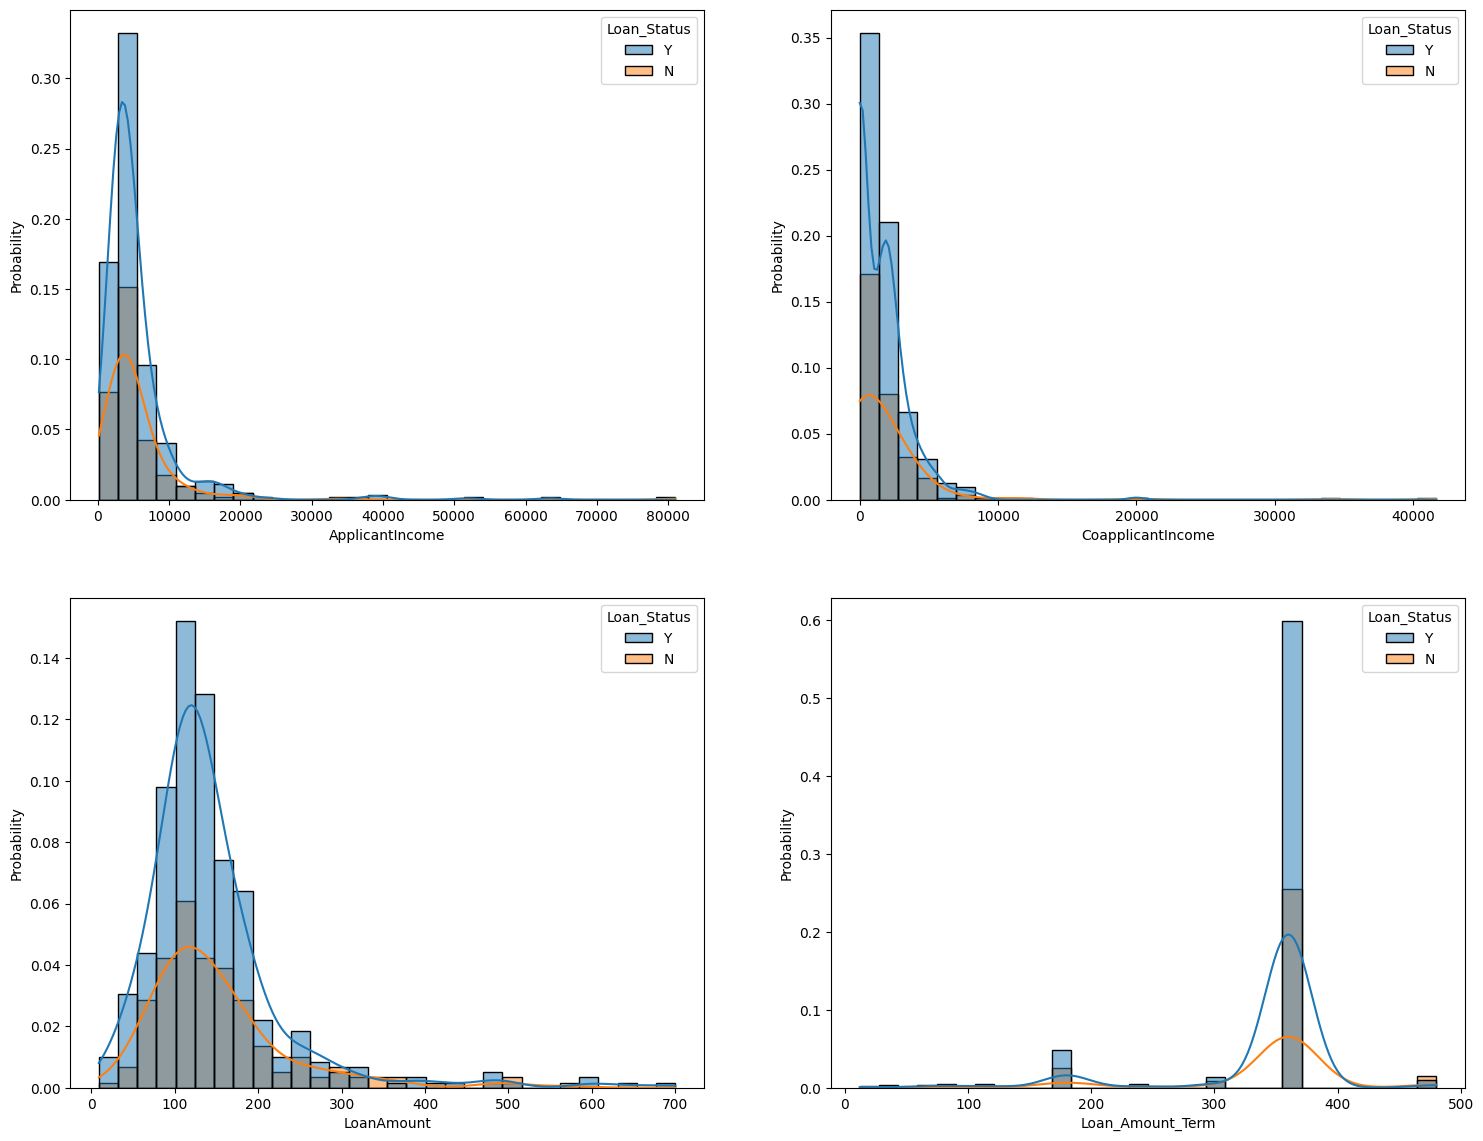

In [35]:
fig,axes= plt.subplots(2,2,figsize=(18,14))
axes=axes.flatten()
i=0
for cols in num_cols:
    sns.histplot(x=cols,hue='Loan_Status',stat='probability',kde=True,ax=axes[i],data=df,bins=30)
    i+=1

##### There is no as such influence of ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term on Loan_Status

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,FunctionTransformer,StandardScaler

In [37]:
df['Dependents'] = df['Dependents'].replace('3+',3)

In [38]:
X_train,X_test,Y_train,Y_test= train_test_split(df.drop(columns='Loan_Status'),df['Loan_Status'],test_size=0.2,random_state=42)

In [39]:
X_train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [40]:
df.nunique()

Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [41]:
remove = ['Dependents','Credit_History']
cat_col = [x for x in cat_cols if x not in remove]

In [42]:
cat_col

['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

In [43]:
num_cols

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [45]:
cat_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
])

In [46]:
cat_remain_pipe = Pipeline([
    ('dependent',SimpleImputer(strategy='most_frequent')),
    ('credit_history',SimpleImputer(strategy='most_frequent'))
])

In [47]:
loan_impute_pipe = Pipeline([
    ('loan_amount',SimpleImputer(strategy='median')),
    ('scaler1',StandardScaler())
])

In [48]:
X_train

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
83,Male,Yes,0,Graduate,No,6000,2250.0,265.0,360.0,NaN,Semiurban
90,Male,Yes,0,Graduate,No,2958,2900.0,131.0,360.0,1.0,Semiurban
227,Male,Yes,2,Graduate,No,6250,1695.0,210.0,360.0,1.0,Semiurban
482,Male,Yes,0,Graduate,No,2083,3150.0,128.0,360.0,1.0,Semiurban
464,Male,No,0,Graduate,No,4166,0.0,98.0,360.0,0.0,Semiurban
...,...,...,...,...,...,...,...,...,...,...,...
71,Male,Yes,2,Not Graduate,Yes,1875,1875.0,97.0,360.0,1.0,Semiurban
106,Male,Yes,2,Graduate,No,11417,1126.0,225.0,360.0,1.0,Urban
270,Female,No,0,Graduate,No,3237,0.0,30.0,360.0,1.0,Urban
435,Female,NaN,NaN,Graduate,No,10047,0.0,NaN,240.0,1.0,Semiurban


In [49]:
X_train['new_ApplicantIncome'] = np.log1p(X_train['ApplicantIncome'])
X_train['new_CoapplicantIncome'] = np.log1p(X_train['CoapplicantIncome'])

In [50]:
X_train[abs(zscore(X_train['new_ApplicantIncome']))>3].shape

(8, 13)

In [51]:
X_train[abs(zscore(X_train['new_CoapplicantIncome']))>3].shape

(0, 13)

##### Here we can see that after log transformation CoapplicantIncome has no outliers but ApplicantIncome still has some

In [52]:
X_train = X_train.drop(columns=['new_ApplicantIncome','new_CoapplicantIncome'])

In [53]:
from sklearn.base import BaseEstimator, TransformerMixin

In [54]:
class IQRCapper(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):

        Q1 = np.quantile(X,0.25)
        Q3 = np.quantile(X,0.75)

        IQR = Q3-Q1

        self.lower = Q1-1.5*IQR
        self.upper = Q3+1.5*IQR

        return self

    def transform(self,X):

        return np.clip(X,self.lower,self.upper)



In [55]:
ApplicantIncome_pipe= Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('iqr', IQRCapper()),
    ('scale',StandardScaler())
])

In [56]:
CoapplicantIncome_pipe= Pipeline([
    ('coapplicantincome',FunctionTransformer(func=np.log1p)),
    ('scaler',StandardScaler())
])

In [57]:
preprocessing = ColumnTransformer([
    ('cat_pipe',cat_pipe,cat_col),
    ('cat_remain_pipe',cat_remain_pipe,['Dependents','Credit_History']),
    ('loan_impute_pipe',loan_impute_pipe,['LoanAmount','Loan_Amount_Term']),
    ('ApplicantIncome_pipe',ApplicantIncome_pipe,['ApplicantIncome']),
    ('CoapplicantIncome_pipe',CoapplicantIncome_pipe,['CoapplicantIncome'])
],remainder='passthrough')

In [58]:
X_train_trans = preprocessing.fit_transform(X_train)
X_test_trans = preprocessing.transform(X_test)

In [59]:
le = LabelEncoder()

In [60]:
Y_train_trans = le.fit_transform(Y_train)

In [61]:
Y_test_trans = le.transform(Y_test)

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [67]:
from sklearn.metrics import classification_report , accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay,roc_curve
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV,cross_val_score
)

In [77]:
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [75]:
lr = LogisticRegression(max_iter=1000)
tree = DecisionTreeClassifier(max_depth=5)
rf = RandomForestClassifier()
knn = KNeighborsClassifier(n_neighbors=10)
svm = SVC(C=10)
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [82]:
def model(give):
    give.fit(X_train_trans,Y_train_trans)
    Y_pred = give.predict(X_test_trans)
    print(f"For {give}")
    print('-'*35)
    print(f"classification_report: ")
    print(classification_report(Y_test_trans,Y_pred))
    print(f"accuracy score is : {accuracy_score(Y_test_trans,Y_pred)}")
    print(f"cross_val_score is : {np.mean(cross_val_score(give,X_train_trans,Y_train_trans,scoring='accuracy',cv=skf))}")
    print('='*35)

In [83]:
model(lr)
model(tree)
model(rf)
model(knn)
model(svm)
model(xgb)

For LogisticRegression(max_iter=1000)
-----------------------------------
classification_report: 
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

accuracy score is : 0.7886178861788617
cross_val_score is : 0.8126938775510204
For DecisionTreeClassifier(max_depth=5)
-----------------------------------
classification_report: 
              precision    recall  f1-score   support

           0       0.77      0.40      0.52        43
           1       0.74      0.94      0.83        80

    accuracy                           0.75       123
   macro avg       0.76      0.67      0.68       123
weighted avg       0.75      0.75      0.72       123

accuracy score is : 0.7479674796747967
cross_val_score is : 0.7863265

In [84]:
from imblearn.over_sampling import SMOTE

In [85]:
ros = SMOTE(random_state=42)
X_train_resampled , Y_train_resampled = ros.fit_resample(X_train_trans,Y_train_trans)

In [86]:
def model1(give):
    give.fit(X_train_resampled,Y_train_resampled)
    Y_pred = give.predict(X_test_trans)
    print(f"For {give}")
    print('-'*35)
    print(f"classification_report: ")
    print(classification_report(Y_test_trans,Y_pred))
    print(f"accuracy score is : {accuracy_score(Y_test_trans,Y_pred)}")
    print(f"cross_val_score is : {np.mean(cross_val_score(give,X_train_resampled,Y_train_resampled,scoring='accuracy',cv=10))}")
    print('='*35)

In [87]:
lr = LogisticRegression(max_iter=1000)
tree = DecisionTreeClassifier(max_depth=5)
rf = RandomForestClassifier(max_depth=5,n_estimators=10)
knn = KNeighborsClassifier(n_neighbors=10)
svm = SVC(C=10)

In [88]:
model1(lr)
model1(tree)
model1(rf)
model1(knn)
model1(svm)
model1(xgb)

For LogisticRegression(max_iter=1000)
-----------------------------------
classification_report: 
              precision    recall  f1-score   support

           0       0.64      0.49      0.55        43
           1       0.76      0.85      0.80        80

    accuracy                           0.72       123
   macro avg       0.70      0.67      0.68       123
weighted avg       0.71      0.72      0.71       123

accuracy score is : 0.7235772357723578
cross_val_score is : 0.7223998294970162
For DecisionTreeClassifier(max_depth=5)
-----------------------------------
classification_report: 
              precision    recall  f1-score   support

           0       0.90      0.44      0.59        43
           1       0.76      0.97      0.86        80

    accuracy                           0.79       123
   macro avg       0.83      0.71      0.73       123
weighted avg       0.81      0.79      0.77       123

accuracy score is : 0.7886178861788617
cross_val_score is : 0.7752983

In [89]:
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

In [90]:
grid_lr = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000
    ),
    param_grid=lr_params,
    scoring='f1_macro',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

grid_lr.fit(
    X_train_resampled,
    Y_train_resampled
)

Fitting 10 folds for each of 12 candidates, totalling 120 fits


,estimator,LogisticRegre...max_iter=2000)
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [91]:
grid_lr.best_params_

{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

In [92]:
grid_lr.best_score_

np.float64(0.7273313218243653)

In [93]:
lr1 = LogisticRegression(C=1,penalty='l2',solver='liblinear')

In [94]:
model1(lr1)

For LogisticRegression(C=1, solver='liblinear')
-----------------------------------
classification_report: 
              precision    recall  f1-score   support

           0       0.71      0.51      0.59        43
           1       0.77      0.89      0.83        80

    accuracy                           0.76       123
   macro avg       0.74      0.70      0.71       123
weighted avg       0.75      0.76      0.74       123

accuracy score is : 0.7560975609756098
cross_val_score is : 0.7238704177323102


In [95]:
svm_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

In [96]:
grid_svm = GridSearchCV(
    estimator=SVC(
        probability=True,
        random_state=42
    ),
    param_grid=svm_params,
    scoring='f1_macro',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(
    X_train_trans,
    Y_train_trans
)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


,estimator,SVC(probabili...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [97]:
print("Best parameters:")
print(grid_svm.best_params_)

print("\nBest CV Macro F1:")
print(grid_svm.best_score_)

Best parameters:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Best CV Macro F1:
0.729274383832543


In [100]:
best_svm = grid_svm.best_estimator_
model(best_svm)


For SVC(C=10, gamma='auto', probability=True, random_state=42)
-----------------------------------
classification_report: 
              precision    recall  f1-score   support

           0       0.86      0.44      0.58        43
           1       0.76      0.96      0.85        80

    accuracy                           0.78       123
   macro avg       0.81      0.70      0.72       123
weighted avg       0.80      0.78      0.76       123

accuracy score is : 0.7804878048780488
cross_val_score is : 0.8066530612244897


In [101]:
RandomForestClassifier()
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_params,
    scoring='f1_macro',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(
    X_train_trans,
    Y_train_trans
)

Fitting 10 folds for each of 270 candidates, totalling 2700 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 3, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [103]:
best_rf = grid_rf.best_estimator_
model(best_rf)

For RandomForestClassifier(max_depth=10, min_samples_split=5, n_jobs=-1,
                       random_state=42)
-----------------------------------
classification_report: 
              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123

accuracy score is : 0.7723577235772358
cross_val_score is : 0.814857142857143


In [104]:
XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=xgb_params,
    scoring='f1_macro',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(
    X_train_trans,
    Y_train_trans
)
print("Best XGBoost parameters:")
print(grid_xgb.best_params_)

print("\nBest CV Macro F1:")
print(grid_xgb.best_score_)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
Best XGBoost parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}

Best CV Macro F1:
0.7406449420816663


In [105]:
best_xgb = grid_xgb.best_estimator_
model(best_xgb)

For XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)
-----------------------------------
classification_report: 
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80


In [106]:
Y_prob_xgb = best_xgb.predict_proba(
    X_test_trans
)[:, 1]

In [108]:
from sklearn.metrics import classification_report

thresholds = [
    0.50,
    0.55,
    0.60,
    0.45,
    0.40,
    0.65
]

for threshold in thresholds:

    Y_pred_threshold = (
        Y_prob_xgb >= threshold
    ).astype(int)

    print("=" * 60)
    print("Threshold:", threshold)

    print(
        classification_report(
            Y_test_trans,
            Y_pred_threshold
        )
    )

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

Threshold: 0.55
              precision    recall  f1-score   support

           0       0.86      0.44      0.58        43
           1       0.76      0.96      0.85        80

    accuracy                           0.78       123
   macro avg       0.81      0.70      0.72       123
weighted avg       0.80      0.78      0.76       123

Threshold: 0.6
              precision    recall  f1-score   support

           0       0.70      0.44      0.54        43
           1       0.75      0.90      0.82        80

    accuracy                           0.74       123
   macro avg       0.73      0.67      0.68       123
weighted avg       0.73     

In [109]:
lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
model(lr_balanced)

For LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
-----------------------------------
classification_report: 
              precision    recall  f1-score   support

           0       0.65      0.47      0.54        43
           1       0.75      0.86      0.80        80

    accuracy                           0.72       123
   macro avg       0.70      0.66      0.67       123
weighted avg       0.71      0.72      0.71       123

accuracy score is : 0.7235772357723578
cross_val_score is : 0.7596326530612244


In [110]:
Y_prob = best_xgb.predict_proba(X_test_trans)[:, 1]

In [111]:
fpr, tpr, thresholds = roc_curve(
    Y_test_trans,
    Y_prob
)

ROC-AUC Score: 0.7209302325581396


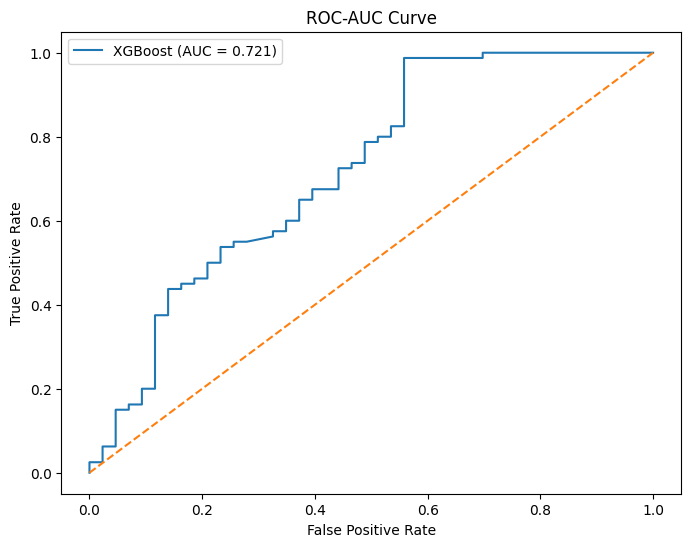

In [112]:
auc = roc_auc_score(
    Y_test_trans,
    Y_prob
)

print("ROC-AUC Score:", auc)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost (AUC = {auc:.3f})'
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve")

plt.legend()

plt.show()